## **CELL 1 — Environment Setup**

In [1]:
# CELL 1 — Environment Setup
!pip install -q grad-cam seaborn

import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES = ["COVID", "Normal", "Viral Pneumonia", "Lung_Opacity"]
print(f"Using device: {DEVICE}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using device: cuda


## **Dataset Class with CLAHE Preprocessing**

In [2]:
# CELL 2 — Dataset Class with CLAHE Preprocessing
# Every image passes through this pipeline before EfficientNet-B4

import os
import cv2
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

class FinalCOVIDDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths, self.labels, self.transform = image_paths, labels, transform

        # clipLimit=2.0  : controls contrast enhancement strength
        # tileGridSize   : divides image into 8x8 tiles, equalizes locally
        #                  better than global EQ for X-rays (varying local contrast)
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Step 1: Load in grayscale — X-rays are grayscale by nature
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)

        # Step 2: Apply CLAHE — enhances opacity patterns for COVID detection
        img = self.clahe.apply(img)

        # Step 3: Grayscale → RGB — EfficientNet-B4 expects 3-channel input
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_GRAY2RGB))

        # Step 4: Apply transforms (augmentation for train, normalize only for val/test)
        if self.transform:
            img = self.transform(img)

        # Returns tensor (3, 380, 380) + integer label
        # 0=COVID, 1=Normal, 2=Viral Pneumonia, 3=Lung_Opacity
        return img, self.labels[idx]

print("FinalCOVIDDataset defined")

FinalCOVIDDataset defined


## **CLAHE Verification (Visual Check)**

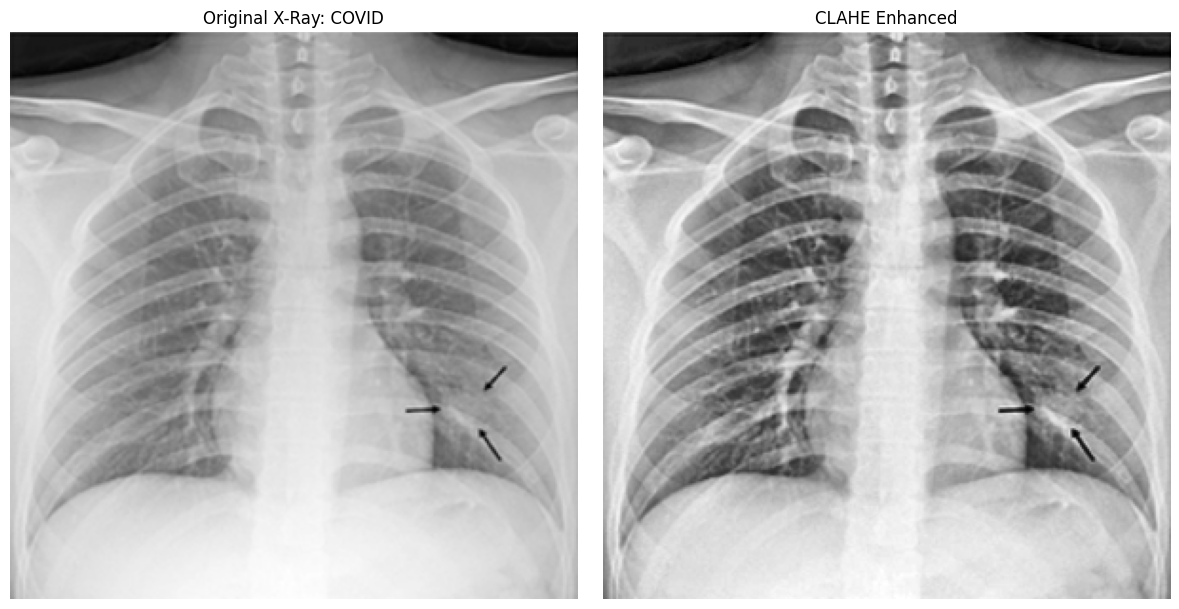

----------------------------------------------------------------------
Enhancement Process Complete
Successfully verified CLAHE for image: COVID-130.png
----------------------------------------------------------------------


In [5]:
# CELL 3 — CLAHE Verification (Visual Check)
import random, os, cv2
import matplotlib.pyplot as plt

DATA_DIR     = "./COVID-19_Radiography_Dataset"
target_class = "COVID"

# Download dataset if not present
if not os.path.exists(DATA_DIR):
    print("Dataset not found. Downloading...")
    !pip install -q kaggle
    !kaggle datasets download -d tawsifurrahman/covid19-radiography-database --unzip
    print("Download complete.")

class_folder = os.path.join(DATA_DIR, target_class, "images")

all_files    = [f for f in os.listdir(class_folder)
                if f.endswith(('.png', '.jpg', '.jpeg'))]
random_file  = random.choice(all_files)
full_path    = os.path.join(class_folder, random_file)

original_img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
test_clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced_img = test_clahe.apply(original_img)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(original_img, cmap='gray')
plt.title(f"Original X-Ray: {target_class}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(enhanced_img, cmap='gray')
plt.title("CLAHE Enhanced")
plt.axis('off')

plt.tight_layout()
plt.show()

print("-" * 70)
print("Enhancement Process Complete")
print(f"Successfully verified CLAHE for image: {random_file}")
print("-" * 70)

## **Split the Dataset (80/10/10)**

In [6]:
# CELL 4 — Split the Dataset (80/10/10)
import os
from sklearn.model_selection import train_test_split
from torchvision import transforms

DATA_DIR = "./COVID-19_Radiography_Dataset"
CLASSES  = ["COVID", "Normal", "Viral Pneumonia", "Lung_Opacity"]

image_paths, labels = [], []

for idx, cls in enumerate(CLASSES):
    path  = os.path.join(DATA_DIR, cls, "images")
    files = [os.path.join(path, f) for f in os.listdir(path)
             if f.endswith(('.png', '.jpg', '.jpeg'))]
    image_paths.extend(files)
    labels.extend([idx] * len(files))
    print(f"  {cls}: {len(files)} images")

print(f"\nTotal: {len(image_paths)} images")

# random_state=42 is fixed — keeps test set identical every run
X_train_val, X_test, y_train_val, y_test = train_test_split(
    image_paths, labels,
    test_size=0.10, stratify=labels, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.1111, stratify=y_train_val, random_state=42
)

# Val/test transform — deterministic, no augmentation
val_tf = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print(f"\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print("Splits ready.")

  COVID: 3616 images
  Normal: 10192 images
  Viral Pneumonia: 1345 images
  Lung_Opacity: 6012 images

Total: 21165 images

Train: 16931 | Val: 2117 | Test: 2117
Splits ready.


## **Master Block: Stage 1 Warm-Up (5 epochs, head only)**

In [7]:
# CELL 5 — Master Block: Stage 1 Warm-Up (5 epochs, head only)
# ── Fixed: uses torch.amp (not deprecated autocast), num_workers=2,
#           RandomRotation + ColorJitter in train_tf ──────────────

import os
import cv2
import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

# 1. Re-download dataset if VM reset wiped it
if not os.path.exists("./COVID-19_Radiography_Dataset"):
    print("Dataset missing. Re-downloading from Kaggle...")
    !pip install -q kaggle
    !kaggle datasets download -d tawsifurrahman/covid19-radiography-database --unzip
    print("Download complete.")

# 2. Core settings
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES = ["COVID", "Normal", "Viral Pneumonia", "Lung_Opacity"]

# 3. Dataset class (self-contained so this cell always works after reset)
class FinalCOVIDDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths, self.labels, self.transform = image_paths, labels, transform
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        img = self.clahe.apply(img)
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_GRAY2RGB))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

# 4. Gather all image paths + integer labels
image_paths, labels = [], []
for idx, cls in enumerate(CLASSES):
    path = os.path.join("./COVID-19_Radiography_Dataset", cls, "images")
    if os.path.exists(path):
        files = [os.path.join(path, f) for f in os.listdir(path)
                 if f.endswith(('.png', '.jpg', '.jpeg'))]
        image_paths.extend(files)
        labels.extend([idx] * len(files))

# 5. 80/10/10 split — random_state=42 keeps test set identical every run
X_train_val, X_test, y_train_val, y_test = train_test_split(
    image_paths, labels,
    test_size=0.10, stratify=labels, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.1111, stratify=y_train_val, random_state=42)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# 6. Transforms
train_tf = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 7. DataLoaders — num_workers=2 for T4, avoids freeze warning
train_loader = DataLoader(FinalCOVIDDataset(X_train, y_train, train_tf),
                          batch_size=64, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(FinalCOVIDDataset(X_val, y_val, val_tf),
                          batch_size=64,
                          num_workers=2, pin_memory=True)

# 8. EfficientNet-B4 — freeze backbone, train head only for Stage 1
model = models.efficientnet_b4(
    weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1).to(DEVICE)
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features, len(CLASSES)).to(DEVICE)

for param in model.features.parameters():
    param.requires_grad = False   # backbone frozen

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
scaler    = torch.amp.GradScaler('cuda')

print(f"\nStarting Stage 1 Warm-up on {DEVICE}...")
print(f"Verified: {len(X_train)} images in training set.")

# 9. Stage 1: 5 warm-up epochs (head only)
for epoch in range(5):
    model.train()
    correct, total = 0, 0
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/5"):
        images  = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss    = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        _, predicted = outputs.max(1)
        total   += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    print(f"Epoch {epoch+1}/5 | Warm-up Acc: {100.*correct/total:.2f}%")

Train: 16931 | Val: 2117 | Test: 2117
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 171MB/s]



Starting Stage 1 Warm-up on cuda...
Verified: 16931 images in training set.


Epoch 1/5: 100%|██████████| 265/265 [03:59<00:00,  1.10it/s]


Epoch 1/5 | Warm-up Acc: 69.52%


...

Epoch 3/5 | Warm-up Acc: 79.61%


Epoch 4/5: 100%|██████████| 265/265 [03:49<00:00,  1.16it/s]


Epoch 4/5 | Warm-up Acc: 80.20%


Epoch 5/5: 100%|██████████| 265/265 [03:48<00:00,  1.16it/s]

Epoch 5/5 | Warm-up Acc: 81.13%


## **Stage 2: Full Fine-Tuning (35 epochs, all layers)**

In [8]:
# CELL 6 — Stage 2: Full Fine-Tuning (35 epochs, all layers)
# ── Continues from Cell 5 warm-up weights — does NOT re-initialize model ──
# ── Unfreezes backbone, lowers LR to 1e-5, gradient accumulation = eff. batch 64 ──

import torch
import gc
from torch.utils.data import DataLoader

# 1. Free optimizer memory only — keep model weights from Stage 1!
if 'optimizer' in locals(): del optimizer
torch.cuda.empty_cache()
gc.collect()

# 2. Reduced batch size for VRAM stability on T4
BATCH_SIZE         = 16
ACCUMULATION_STEPS = 4    # 16 x 4 = effective batch size of 64

train_loader = DataLoader(
    FinalCOVIDDataset(X_train, y_train, train_tf),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    FinalCOVIDDataset(X_val, y_val, val_tf),
    batch_size=BATCH_SIZE,
    num_workers=2, pin_memory=True
)

# 3. Unfreeze entire backbone for Stage 2
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5)
scaler    = torch.amp.GradScaler('cuda')
criterion = nn.CrossEntropyLoss()

print("--- STAGE 2: FULL FINE-TUNING (35 epochs) ---")
print(f"Effective Batch: {BATCH_SIZE * ACCUMULATION_STEPS} | Target: Val Acc >= 93%")

for epoch in range(35):
    model.train()
    correct, total = 0, 0
    optimizer.zero_grad()

    for i, (images, targets) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/35")):
        images  = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss    = criterion(outputs, targets) / ACCUMULATION_STEPS
        scaler.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        _, predicted = outputs.max(1)
        total   += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            outputs         = model(images)
            _, predicted    = outputs.max(1)
            val_total   += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()

    val_acc = 100. * val_correct / val_total
    print(f"Epoch {epoch+1}/35 | Train Acc: {100.*correct/total:.2f}% "
          f"| Val Acc: {val_acc:.2f}% | Target: 93%")

    if val_acc >= 93.0:
        torch.save(model.state_dict(), f"best_model_acc_{val_acc:.1f}.pth")
        print(f"  ★ Checkpoint saved: best_model_acc_{val_acc:.1f}.pth")

# Always save final epoch — never lose weights to a runtime reset
torch.save(model.state_dict(), "final_model_epoch35.pth")
print("\nFinal model saved → final_model_epoch35.pth")
print("IMPORTANT: Download now via Files panel → right-click → Download")

--- STAGE 2: FULL FINE-TUNING (35 epochs) ---
Effective Batch: 64 | Target: Val Acc >= 93%


Epoch 1/35: 100%|██████████| 1059/1059 [06:13<00:00,  2.83it/s]


Epoch 1/35 | Train Acc: 80.61% | Val Acc: 84.55% | Target: 93%


Epoch 2/35: 100%|██████████| 1059/1059 [05:46<00:00,  3.06it/s]


Epoch 2/35 | Train Acc: 82.18% | Val Acc: 85.64% | Target: 93%


...

Epoch 33/35 | Train Acc: 92.71% | Val Acc: 92.44% | Target: 93%


Epoch 34/35: 100%|██████████| 1059/1059 [05:44<00:00,  3.07it/s]


Epoch 34/35 | Train Acc: 93.00% | Val Acc: 92.77% | Target: 93%


Epoch 35/35: 100%|██████████| 1059/1059 [05:45<00:00,  3.06it/s]


Epoch 35/35 | Train Acc: 93.13% | Val Acc: 92.11% | Target: 93%

Final model saved → final_model_epoch35.pth
IMPORTANT: Download now via Files panel → right-click → Download


## **Final Evaluation on Test Set**

--- Evaluating on 2117 Test Images ---
On GPU: ~10-15 min | On CPU: ~1 min



Evaluating: 100%|██████████| 265/265 [00:36<00:00,  7.34it/s]



--- FINAL CLASSIFICATION REPORT ---
                 precision    recall  f1-score   support

          COVID       0.88      0.98      0.93       362
         Normal       0.94      0.95      0.95      1019
Viral Pneumonia       0.97      0.97      0.97       135
   Lung_Opacity       0.95      0.86      0.90       601

       accuracy                           0.93      2117
      macro avg       0.93      0.94      0.94      2117
   weighted avg       0.93      0.93      0.93      2117



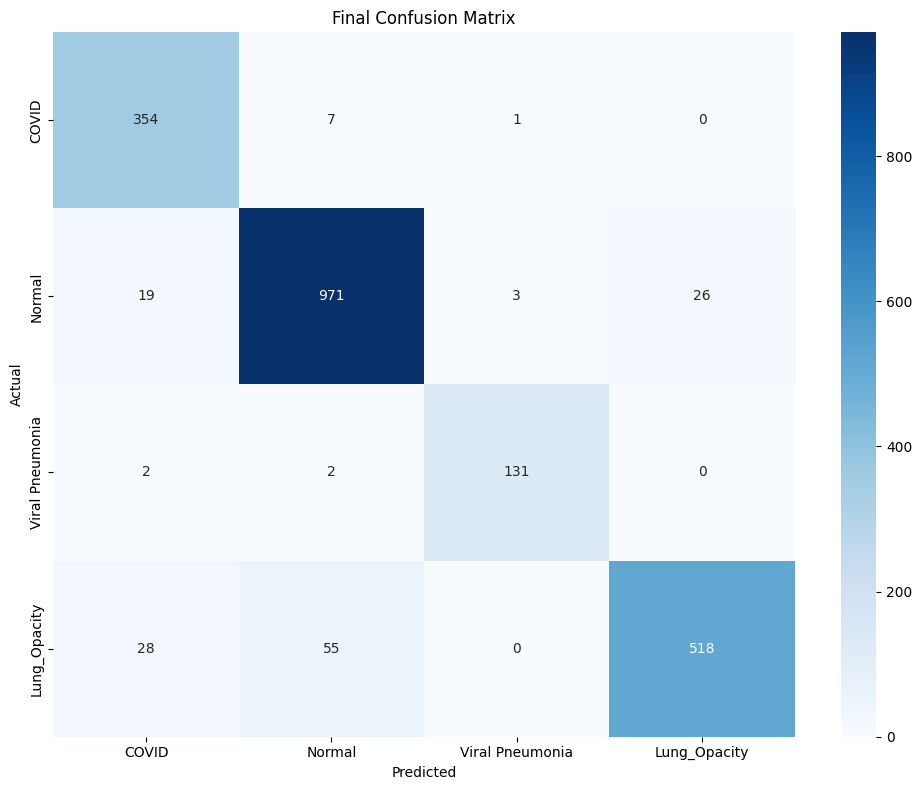

  Final Test Accuracy : 93.25%
  COVID Recall        : 97.79%

  BELOW TARGET — Test accuracy 93.25% does not meet ≥ 95%.
     (gap: 1.75% away from target)
  PASSED — COVID recall 97.79% meets the ≥ 95% clinical target!


In [9]:
# CELL 7 — Final Evaluation on Test Set
# ── Runs on CPU or GPU — settings adjusted for both ──────────────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds, all_targets = [], []

test_loader = DataLoader(
    FinalCOVIDDataset(X_test, y_test, val_tf),
    batch_size  = 8,
    shuffle     = False,
    num_workers = 0
)

print(f"--- Evaluating on {len(X_test)} Test Images ---")
print("On GPU: ~10-15 min | On CPU: ~1 min\n")

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Evaluating"):
        images  = images.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.numpy())

# Classification report
print("\n--- FINAL CLASSIFICATION REPORT ---")
print(classification_report(all_targets, all_preds, target_names=CLASSES))

# Confusion matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Final accuracy summary ────────────────────────────────────────
correct_total = sum(p == t for p, t in zip(all_preds, all_targets))
test_acc      = 100. * correct_total / len(all_targets)

# COVID-specific recall (clinically most important metric)
covid_idx     = CLASSES.index("COVID")
covid_actual  = [t == covid_idx for t in all_targets]
covid_correct = [p == covid_idx for p, t in zip(all_preds, all_targets) if t == covid_idx]
covid_recall  = 100. * sum(covid_correct) / sum(covid_actual)

print("=" * 50)
print(f"  Final Test Accuracy : {test_acc:.2f}%")
print(f"  COVID Recall        : {covid_recall:.2f}%")
print()

if test_acc >= 95.0:
    print(f"  PASSED — Test accuracy {test_acc:.2f}% meets the ≥ 95% target!")
else:
    print(f"  BELOW TARGET — Test accuracy {test_acc:.2f}% does not meet ≥ 95%.")
    print(f"     (gap: {95.0 - test_acc:.2f}% away from target)")

if covid_recall >= 95.0:
    print(f"  PASSED — COVID recall {covid_recall:.2f}% meets the ≥ 95% clinical target!")
else:
    print(f"  BELOW TARGET — COVID recall {covid_recall:.2f}% does not meet ≥ 95%.")
    print(f"     (gap: {95.0 - covid_recall:.2f}% away from target)")

print("=" * 50)

## **Clinical Explainability (Grad-CAM)**

Generating Grad-CAM for 3 test samples...
~30 seconds per image on CPU.

Sample 1/3...


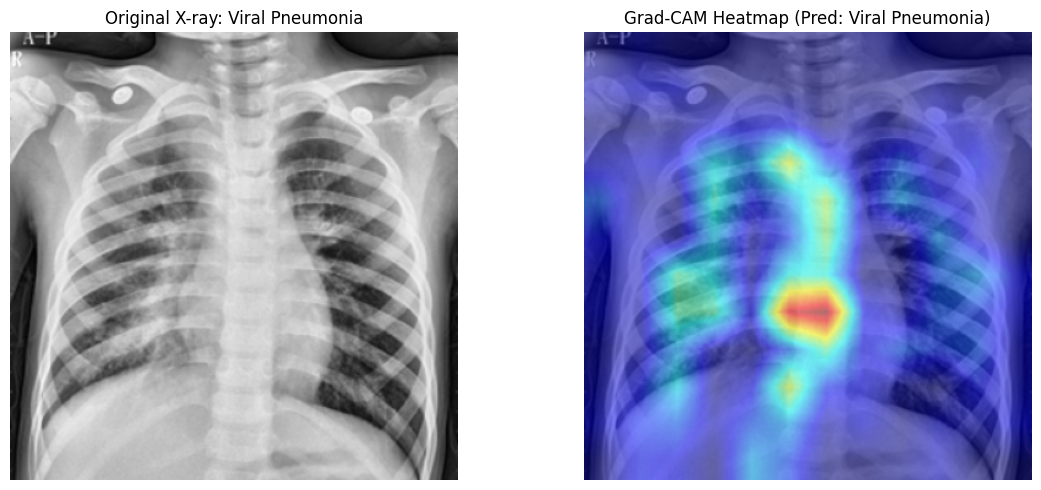

Sample 2/3...


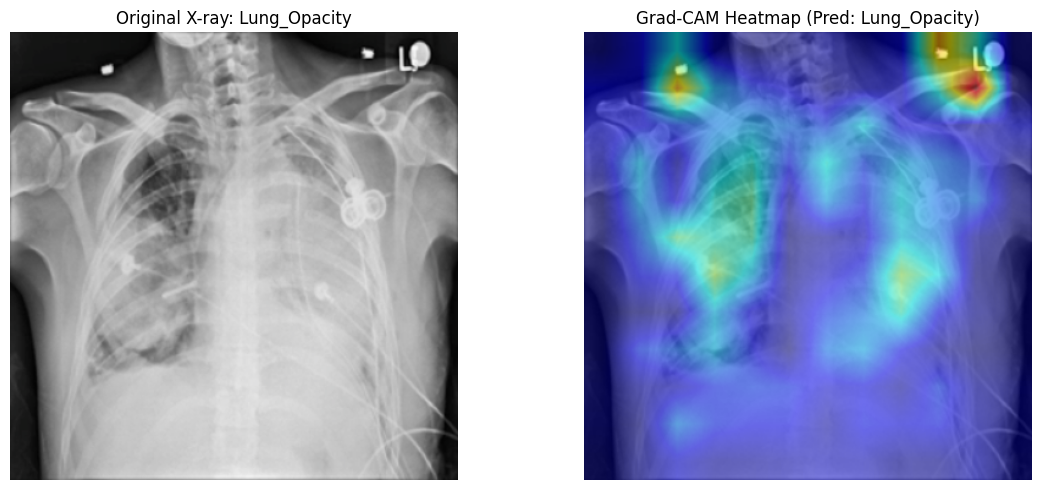

Sample 3/3...


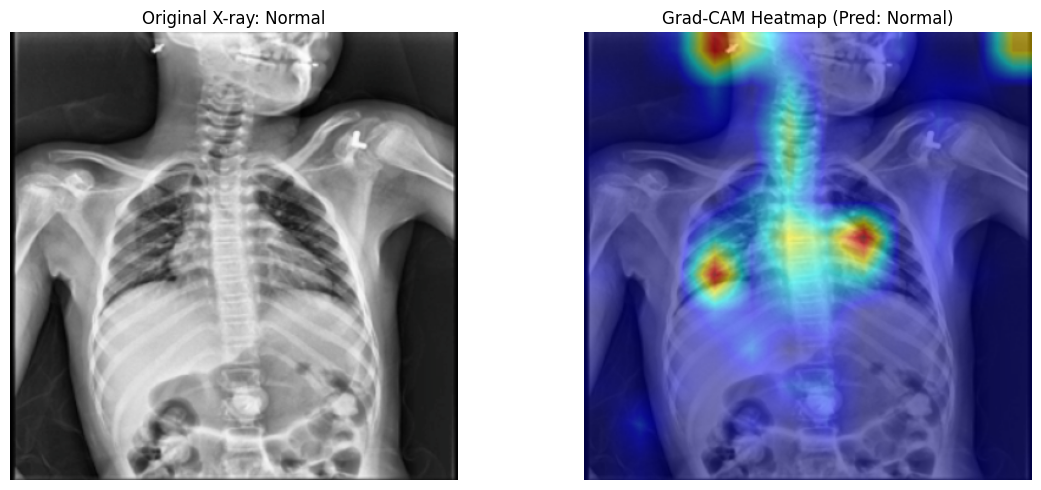

In [10]:
# CELL 8 — Clinical Explainability (Grad-CAM)
# ── Must run AFTER Cell 7 (needs all_preds in memory) ────────────
# ── Fixed: input_tensor moved to CPU first to avoid device mismatch ──

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

# Target the last convolutional block of EfficientNet-B4
# This layer has the most abstract feature maps
# Grad-CAM gradients show which lung regions drove the prediction
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

def plot_clinical_explanation(idx):
    # Load one test image + true label
    img_pil, label = FinalCOVIDDataset(X_test, y_test, val_tf)[idx]

    # Add batch dimension (3,380,380) → (1,3,380,380)
    # Move model to CPU first to avoid device mismatch on CPU runtime
    input_tensor = img_pil.unsqueeze(0).to(next(model.parameters()).device)

    # Generate heatmap for the predicted class
    # Uses all_preds from the evaluation cell above
    targets      = [ClassifierOutputTarget(all_preds[idx])]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    # Denormalise image back to [0,1] for display
    img_np  = img_pil.permute(1, 2, 0).numpy()
    img_np  = (img_np * np.array([0.229, 0.224, 0.225])) \
              + np.array([0.485, 0.456, 0.406])
    img_np  = np.clip(img_np, 0, 1)

    # Overlay heatmap — red/yellow = regions model focused on most
    # Clinical goal: focus should be on lung parenchyma, not borders
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title(f"Original X-ray: {CLASSES[label]}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title(f"Grad-CAM Heatmap (Pred: {CLASSES[all_preds[idx]]})")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Generating Grad-CAM for 3 test samples...")
print("~30 seconds per image on CPU.\n")
for i in range(3):
    print(f"Sample {i+1}/3...")
    plot_clinical_explanation(i)

## **Save Outputs + Recovery Function**

In [ ]:
# CELL 9 — Save Outputs + Recovery Function
from google.colab import files as colab_files

# Save confusion matrix plot
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(all_targets, all_preds),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Final Confusion Matrix')
plt.tight_layout()
plt.savefig("confusion_matrix_final.png", dpi=150, bbox_inches='tight')
print("Saved: confusion_matrix_final.png")

# Save classification report
report = classification_report(all_targets, all_preds, target_names=CLASSES)
with open("classification_report.txt", "w") as f:
    f.write(report)
print("Saved: classification_report.txt")

# Download both immediately
colab_files.download("confusion_matrix_final.png")
colab_files.download("classification_report.txt")
print("\nAll outputs downloaded. Module 1 complete.")

# ── RECOVERY — run this block if runtime resets after training ────
def reload_model(weight_path: str):
    """
    Rebuilds EfficientNet-B4 and loads saved weights.
    Call after a runtime reset, after re-running the Master Block cell.
    """
    device_local = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    m = models.efficientnet_b4(
        weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1
    ).to(device_local)
    m.classifier[1] = nn.Linear(
        m.classifier[1].in_features, len(CLASSES)
    ).to(device_local)

    if not os.path.exists(weight_path):
        print(f"[ERROR] File not found: {weight_path}")
        print("  → Upload your .pth via the Colab Files panel on the left")
        return None

    # map_location handles GPU→CPU and CPU→GPU automatically
    m.load_state_dict(torch.load(weight_path, map_location=device_local))
    m.eval()
    print(f"[OK] Weights loaded onto {device_local}")

    # Sanity check — all probs ~0.25 = loaded correctly
    dummy = torch.zeros(1, 3, 380, 380).to(device_local)
    with torch.no_grad():
        probs = torch.softmax(m(dummy), dim=1)[0]
    print(f"Sanity check: {[f'{p:.3f}' for p in probs.tolist()]}")
    print("All ~0.25 = correct ✓  |  One value near 1.0 = wrong file ✗")
    return m

# ── Usage (after a reset):
# uploaded = colab_files.upload()
# model    = reload_model(list(uploaded.keys())[0])
# DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Then re-run Cell 7 (evaluation) and Cell 8 (Grad-CAM)